# PCHN63112 Workshop: Longitudinal Data Example

## Loading Packages
We will start by loading all the packages that we need at the beginning. This will tidy-up the output, allow any messages or warnings to not clutter up the rest of the output and not bury any packages within the main body of the analysis. We also use `source()` on the file `plot-lme.R`. This needs to be in the current working directory and will bring the custom function `plot.lme()` into scope.

In [1]:
library('lattice')   # plotting functions
library('Matrix')    # covariance extraction and visualisation
library('nlme')      # mixed-effects modelling
library('car')       # Asymptotic ANOVA tests
library('emmeans')   # Follow-up tests
library('effects')   # Effects plots from the model
source('plot-lme.R') # custom plot.lme() function for making assumptions plots

Loading required package: carData
Welcome to emmeans.
Caution: You lose important information if you filter this package's results.
See '? untidy'
Use the command
    lattice::trellis.par.set(effectsTheme())
  to customize lattice options for effects plots.
See ?effectsTheme for details.


## The Autism Data

...

The data are available to download from [here](https://websites.umich.edu/~bwest/chapter6.html). Once downloaded to the current working directory, the code below will read the data in and then print the values for the first 3 children.

In [2]:
autism <- read.csv('autism.csv')
autism[1:14,]

   age vsae sicdegp childid
1    2    6       3       1
2    3    7       3       1
3    5   18       3       1
4    9   25       3       1
5   13   27       3       1
6    2   17       3       3
7    3   18       3       3
8    5   12       3       3
9    9   18       3       3
10  13   24       3       3
11   2   12       3       4
12   3   14       3       4
13   5   38       3       4
14   9  114       3       4

As this is already long-formatted, we just need to convert the relevant variables to factors.

In [37]:
autism$childid <- as.factor(autism$childid)
autism$sicdegp <- as.factor(autism$sicdegp)

levels(autism$sicdegp) <- c('low','medium','high')

We now just briefly summarise all the variables to check everything is in order.

In [38]:
summary(autism)

      age              vsae          sicdegp       childid   
 Min.   : 2.000   Min.   :  1.00   low   :192   1      :  5  
 1st Qu.: 2.000   1st Qu.: 10.00   medium:255   2      :  5  
 Median : 4.000   Median : 14.00   high  :165   3      :  5  
 Mean   : 5.771   Mean   : 26.41                14     :  5  
 3rd Qu.: 9.000   3rd Qu.: 27.00                15     :  5  
 Max.   :13.000   Max.   :198.00                17     :  5  
                  NA's   :2                     (Other):582  

Of note is that VSAE has a very wide range, from 1-198, and also contains two missing values. Also of note is that there are 582 children in the sample, which would be considered very large.

## Data Structure

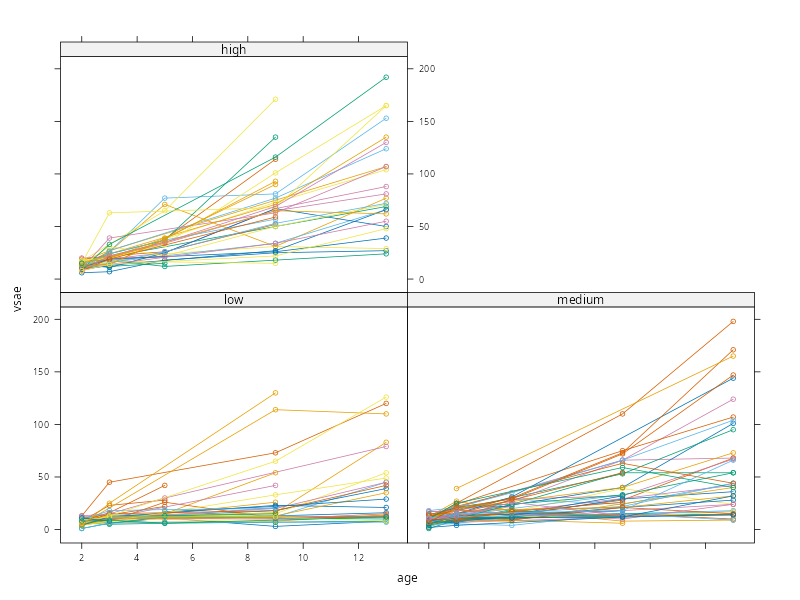

In [39]:
xyplot(
  vsae ~ age|sicdegp, # x-axis=region, panel=treatment
  groups = childid,   # separate lines per-animal
  data   = autism,    # data
  type   = "b"        # lines with points
)

In [40]:
autism.lme <- lme(vsae ~ age*sicdegp, random = ~ 1 + age|childid, data=autism, na.action = na.omit, control=lmeControl(opt='optim'))
summary(autism.lme)

Linear mixed-effects model fit by REML
  Data: autism 
      AIC      BIC    logLik
  4716.13 4760.166 -2348.065

Random effects:
 Formula: ~1 + age | childid
 Structure: General positive-definite, Log-Cholesky parametrization
            StdDev   Corr  
(Intercept) 8.602952 (Intr)
age         4.019888 -0.998
Residual    7.769026       

Fixed effects:  vsae ~ age * sicdegp 
                      Value Std.Error  DF   t-value p-value
(Intercept)        1.843174 1.6899783 449  1.090650  0.2760
age                2.971975 0.6268443 449  4.741170  0.0000
sicdegpmedium     -0.324782 2.2318719 155 -0.145520  0.8845
sicdegphigh       -3.858107 2.4775418 155 -1.557232  0.1215
age:sicdegpmedium  0.715160 0.8290365 449  0.862640  0.3888
age:sicdegphigh    4.334815 0.9181896 449  4.721046  0.0000
 Correlation: 
                  (Intr) age    scdgpm scdgph ag:scdgpm
age               -0.891                               
sicdegpmedium     -0.757  0.675                        
sicdegphigh       -

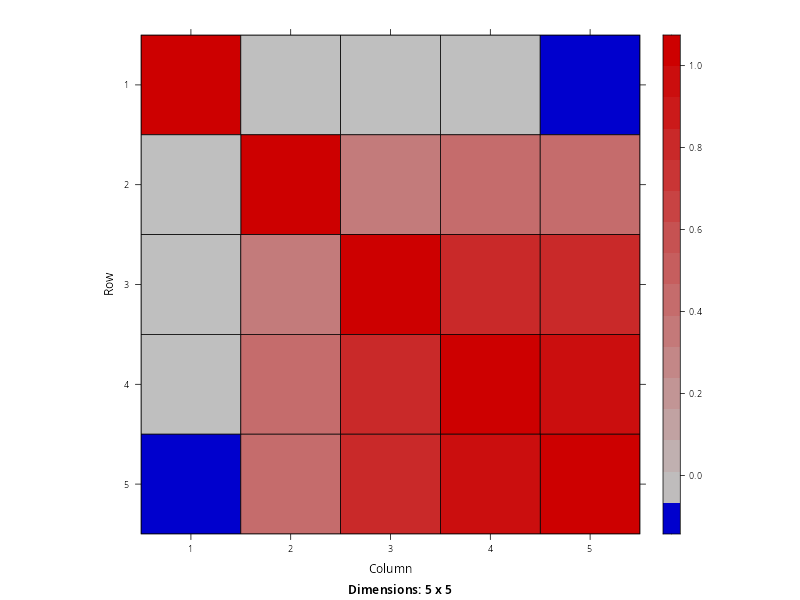

In [50]:
Sigma.1 <- getVarCov(autism.lme, type='marginal', individual='1')$`1`
Corr <- cov2cor(Sigma.1)
image(as(Corr,'Matrix'))

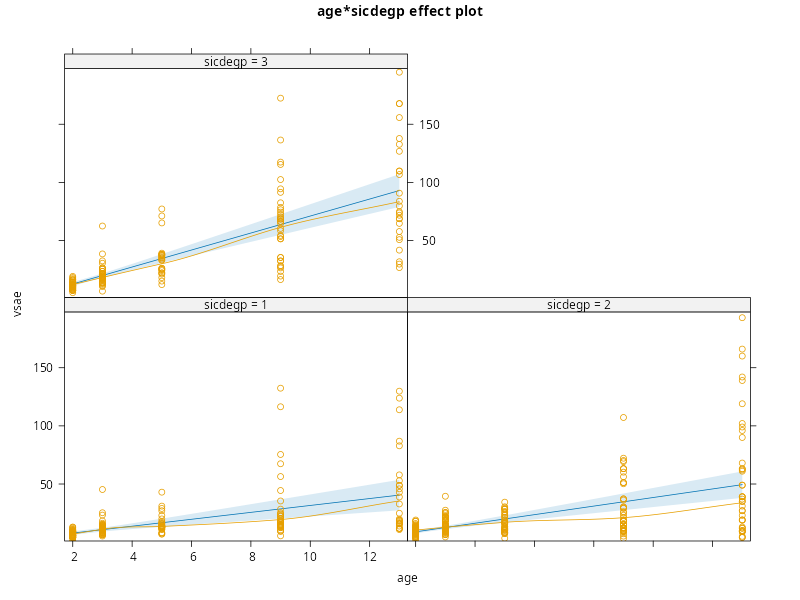

In [31]:
plot(allEffects(autism.lme, residuals=TRUE))

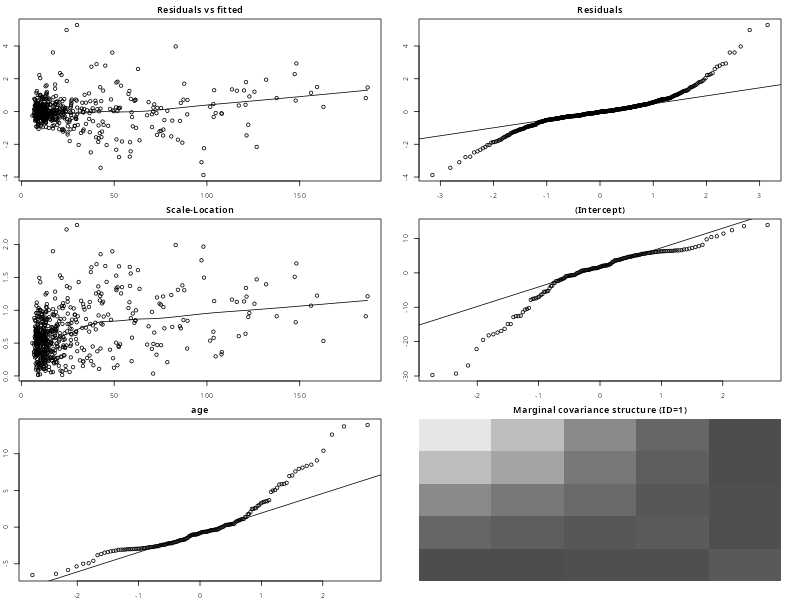

In [43]:
plot.lme(autism.lme, vcov.id='1')

In [33]:
Anova(autism.lme)

Analysis of Deviance Table (Type II tests)

Response: vsae
              Chisq Df Pr(>Chisq)    
age         161.601  1  < 2.2e-16 ***
sicdegp      35.907  2  1.595e-08 ***
age:sicdegp  25.667  2  2.670e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1